In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="darkgrid")

df = pd.read_csv("../data/processed/covid_merged.csv", parse_dates=["date"])
print(f"Shape: {df.shape}")
df.head()

Shape: (221904, 23)


,country,date,confirmed,new_cases,new_cases_7day,deaths,new_deaths,iso_code,reproduction_rate,total_vaccinations_per_hundred,...,hosp_patients_per_million,stringency_index,population,population_density,median_age,gdp_per_capita,human_development_index,hospital_beds_per_thousand,cases_per_million,death_rate
0,Afghanistan,2020-03-01,5,0.0,0.714286,0,0.0,AFG,NaN,NaN,...,NaN,27.78,41128772.0,54.42,18.6,1803.99,0.51,0.5,0.017367,0.0
1,Afghanistan,2020-03-02,5,0.0,0.000000,0,0.0,AFG,NaN,NaN,...,NaN,27.78,41128772.0,54.42,18.6,1803.99,0.51,0.5,0.000000,0.0
2,Afghanistan,2020-03-03,5,0.0,0.000000,0,0.0,AFG,NaN,NaN,...,NaN,27.78,41128772.0,54.42,18.6,1803.99,0.51,0.5,0.000000,0.0
3,Afghanistan,2020-03-04,5,0.0,0.000000,0,0.0,AFG,NaN,NaN,...,NaN,27.78,41128772.0,54.42,18.6,1803.99,0.51,0.5,0.000000,0.0
4,Afghanistan,2020-03-05,5,0.0,0.000000,0,0.0,AFG,NaN,NaN,...,NaN,27.78,41128772.0,54.42,18.6,1803.99,0.51,0.5,0.000000,0.0


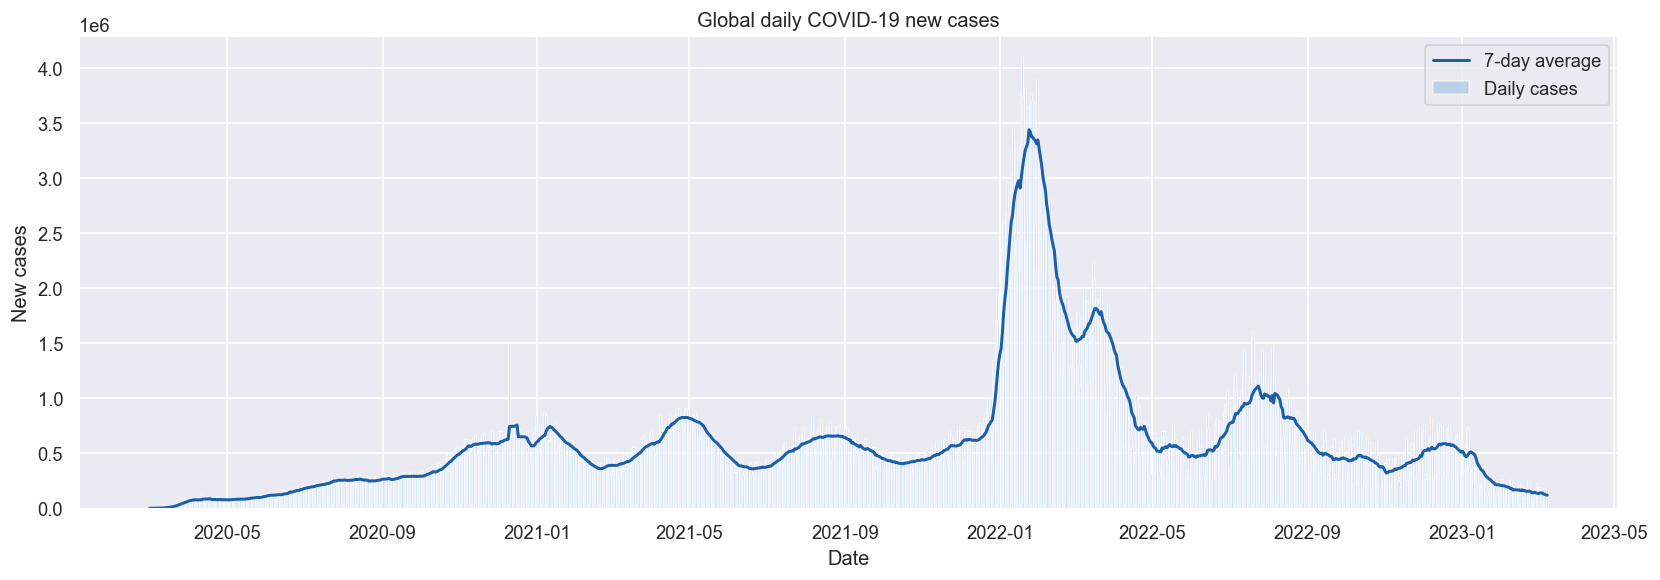

In [2]:
global_daily = df.groupby("date")["new_cases"].sum().reset_index()
global_7day  = global_daily["new_cases"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots()
ax.bar(global_daily["date"], global_daily["new_cases"], color="#90b8e0", alpha=0.5, label="Daily cases")
ax.plot(global_daily["date"], global_7day, color="#1a5fa8", linewidth=1.8, label="7-day average")
ax.set_title("Global daily COVID-19 new cases")
ax.set_xlabel("Date")
ax.set_ylabel("New cases")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/global_cases.png", dpi=120)
plt.show()

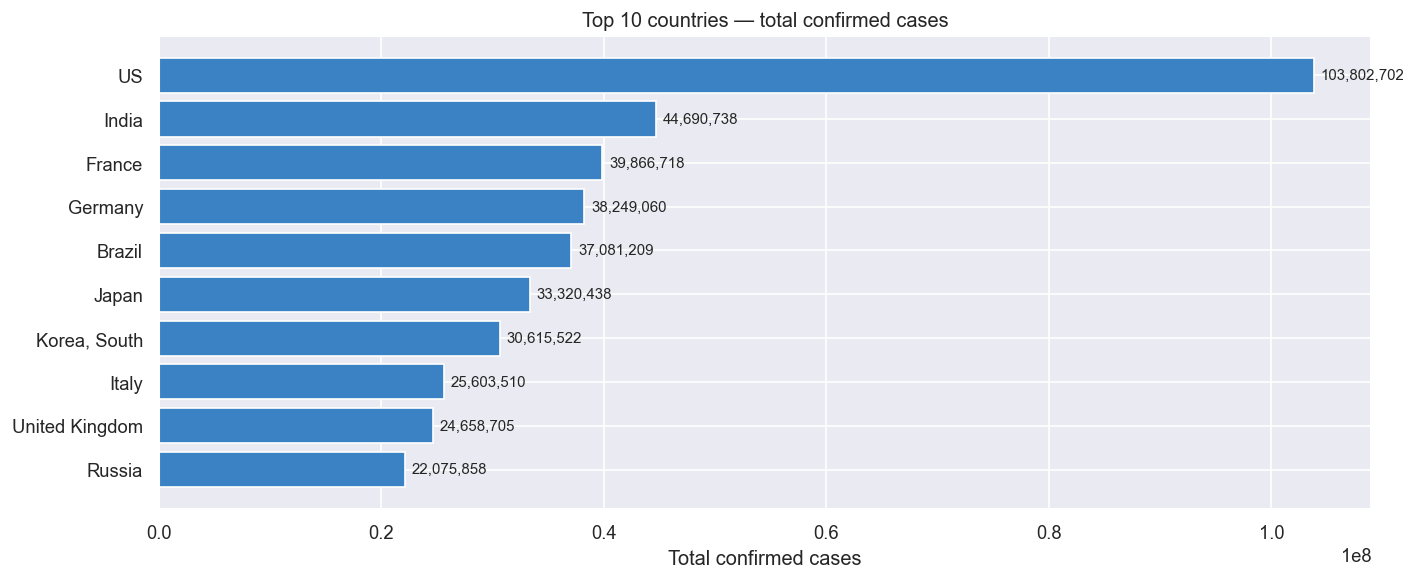

In [3]:
top10 = (
    df.groupby("country")["confirmed"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top10["country"][::-1], top10["confirmed"][::-1], color="#3b82c4")
ax.set_title("Top 10 countries — total confirmed cases")
ax.set_xlabel("Total confirmed cases")
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9)
plt.tight_layout()
plt.savefig("../data/processed/top10_countries.png", dpi=120)
plt.show()

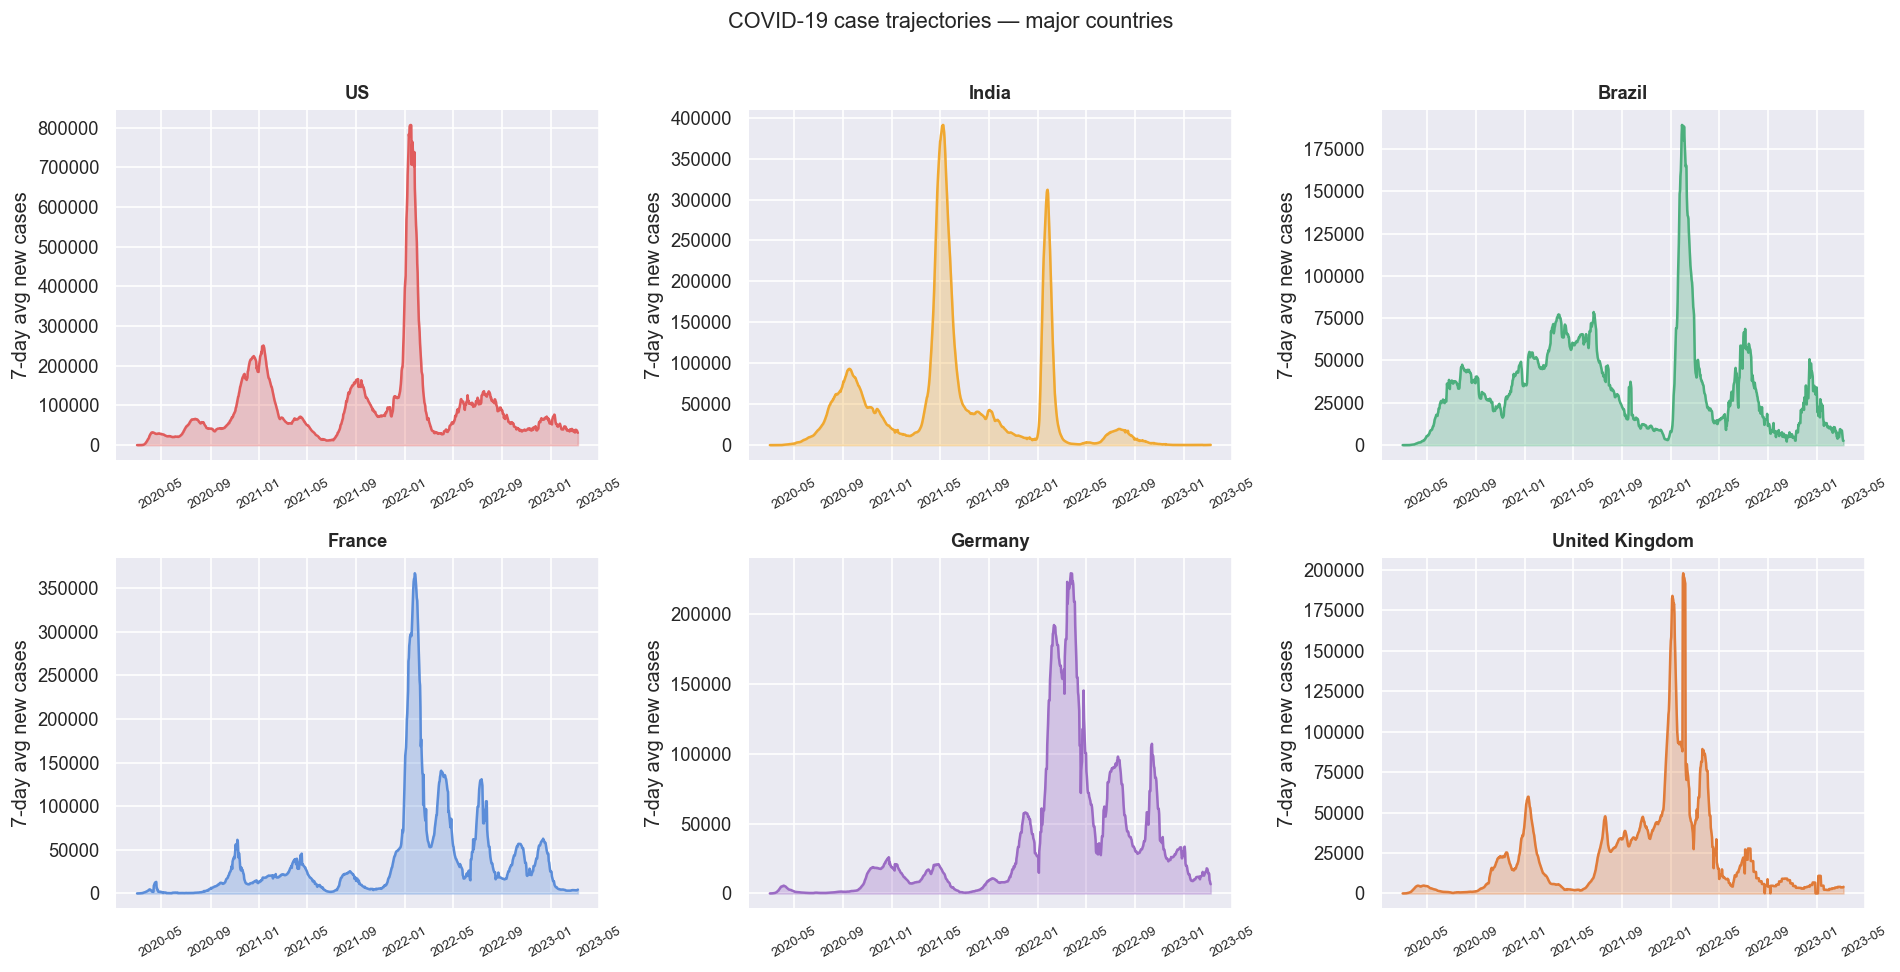

In [4]:
countries = ["US", "India", "Brazil", "France", "Germany", "United Kingdom"]
colors    = ["#e05c5c", "#f0a830", "#4caf7d", "#5b8dd9", "#9b6bc4", "#e07b39"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)

for ax, country, color in zip(axes.flatten(), countries, colors):
    subset = df[df["country"] == country]
    ax.fill_between(subset["date"], subset["new_cases_7day"], alpha=0.3, color=color)
    ax.plot(subset["date"], subset["new_cases_7day"], color=color, linewidth=1.5)
    ax.set_title(country, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("7-day avg new cases")
    ax.tick_params(axis="x", rotation=30, labelsize=8)

plt.suptitle("COVID-19 case trajectories — major countries", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/country_trajectories.png", dpi=120)
plt.show()

E:\anaconda\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


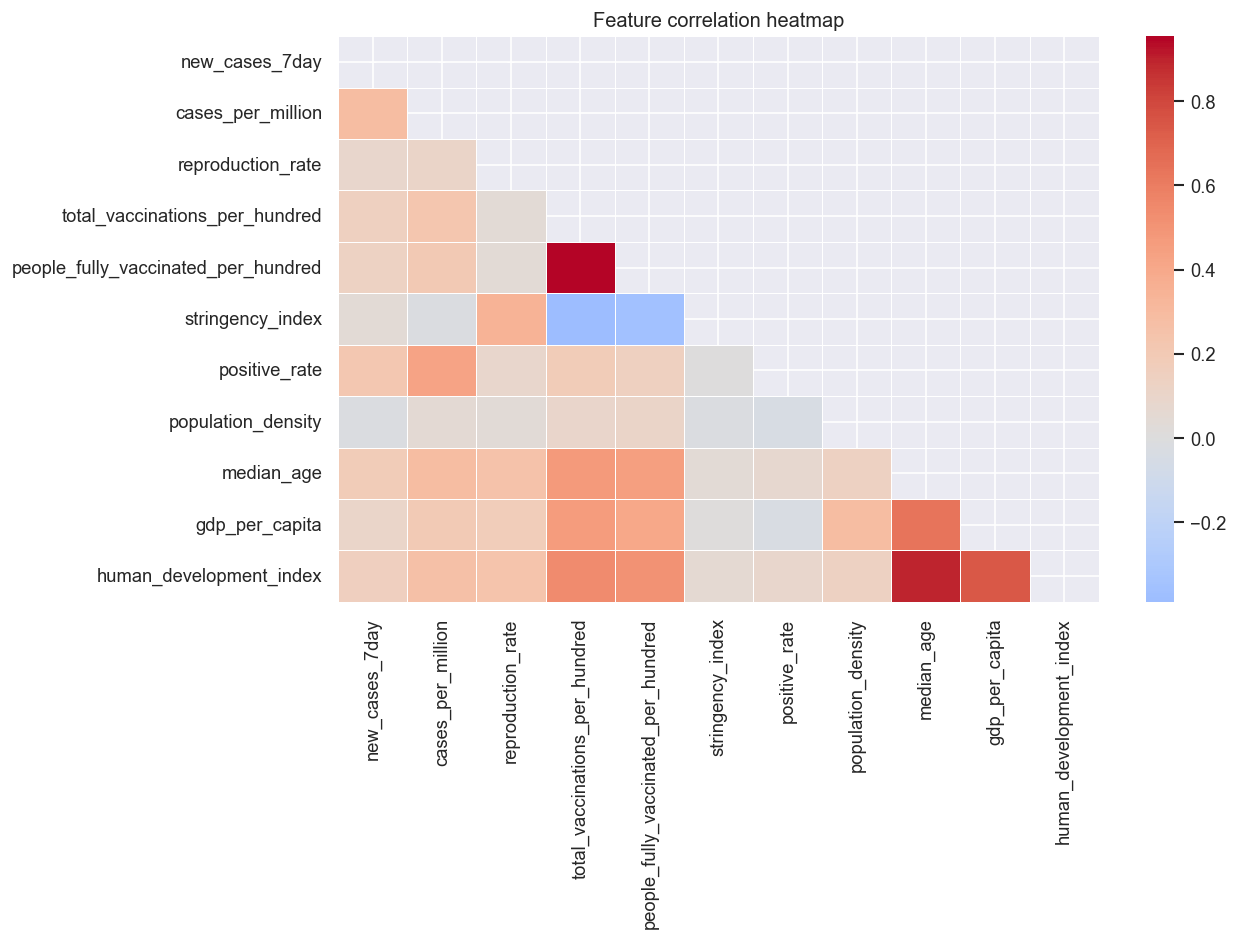

In [5]:
corr_cols = [
    "new_cases_7day", "cases_per_million", "reproduction_rate",
    "total_vaccinations_per_hundred", "people_fully_vaccinated_per_hundred",
    "stringency_index", "positive_rate", "population_density",
    "median_age", "gdp_per_capita", "human_development_index"
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    ax=ax, annot_kws={"size": 8}
)
ax.set_title("Feature correlation heatmap")
plt.tight_layout()
plt.savefig("../data/processed/correlation_heatmap.png", dpi=120)
plt.show()

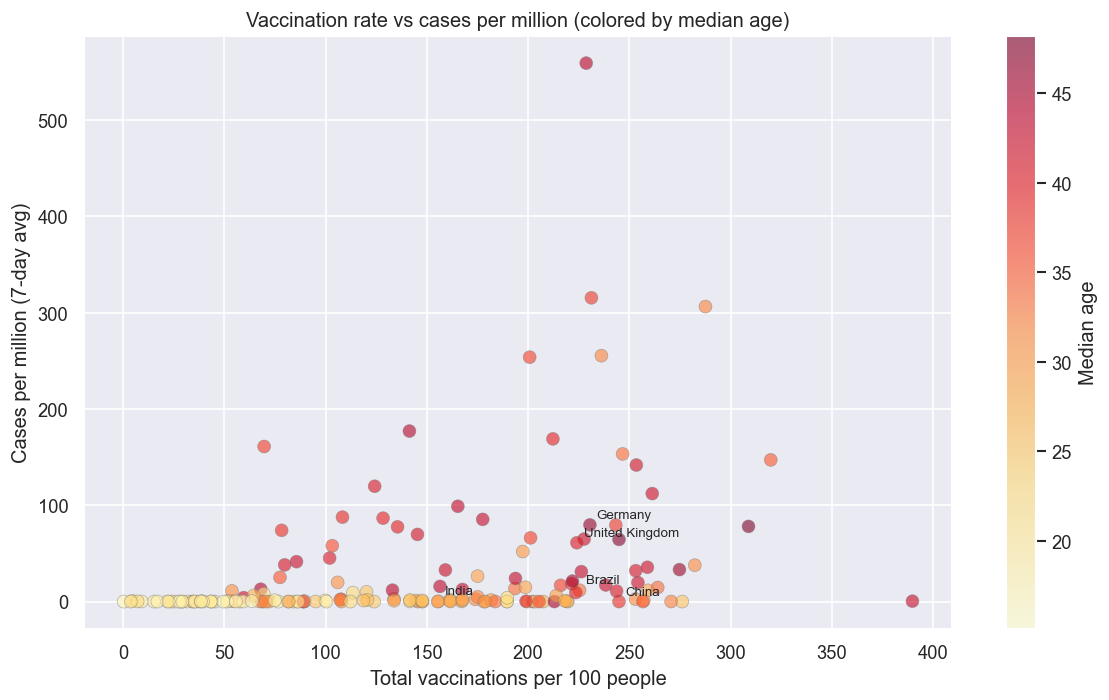

In [6]:
latest = df[df["date"] >= "2021-06-01"].dropna(
    subset=["total_vaccinations_per_hundred", "cases_per_million"]
)
sample = latest.groupby("country").last().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    sample["total_vaccinations_per_hundred"],
    sample["cases_per_million"],
    alpha=0.6, c=sample["median_age"], cmap="YlOrRd", s=60, edgecolors="gray", linewidth=0.4
)
plt.colorbar(sc, ax=ax, label="Median age")

# Label a few notable countries
for _, row in sample[sample["country"].isin(["US", "India", "Brazil", "United Kingdom", "Germany", "China"])].iterrows():
    ax.annotate(row["country"], (row["total_vaccinations_per_hundred"], row["cases_per_million"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_title("Vaccination rate vs cases per million (colored by median age)")
ax.set_xlabel("Total vaccinations per 100 people")
ax.set_ylabel("Cases per million (7-day avg)")
plt.tight_layout()
plt.savefig("../data/processed/vaccination_vs_cases.png", dpi=120)
plt.show()

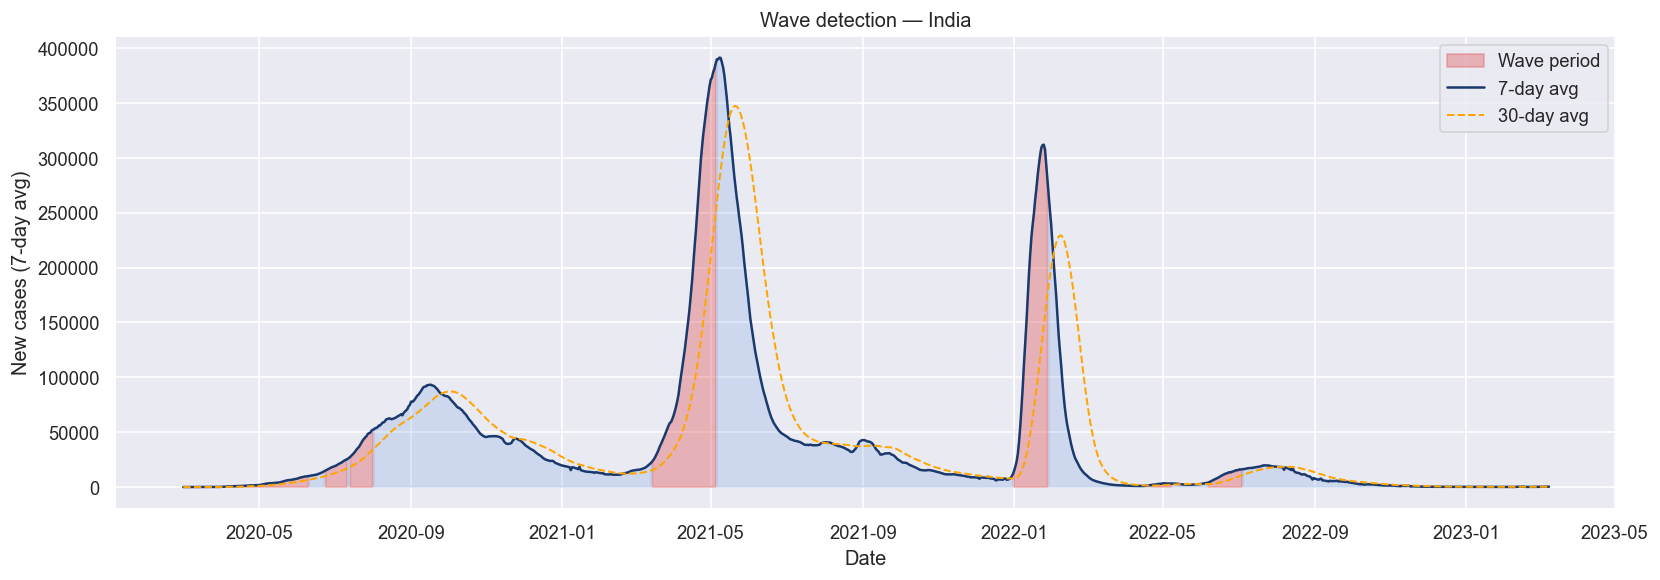

In [7]:
    country = "India"
subset = df[df["country"] == country].copy()

# Simple wave detection: peaks where 7day avg > rolling 30day avg * 1.5
subset["rolling_30"] = subset["new_cases_7day"].rolling(30, min_periods=1).mean()
subset["is_wave"] = subset["new_cases_7day"] > subset["rolling_30"] * 1.5

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(subset["date"], subset["new_cases_7day"],
                where=subset["is_wave"], alpha=0.4, color="#e05c5c", label="Wave period")
ax.fill_between(subset["date"], subset["new_cases_7day"],
                where=~subset["is_wave"], alpha=0.2, color="#5b8dd9")
ax.plot(subset["date"], subset["new_cases_7day"], color="#1a3a6e", linewidth=1.5, label="7-day avg")
ax.plot(subset["date"], subset["rolling_30"], color="orange",
        linewidth=1.2, linestyle="--", label="30-day avg")
ax.set_title(f"Wave detection — {country}")
ax.set_xlabel("Date")
ax.set_ylabel("New cases (7-day avg)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/wave_detection.png", dpi=120)
plt.show()